# 22a. Kundig-Sigrist (2025) — Yearly Panel Construction

Builds `data/processed/kundig_sigrist_yearly_panel.parquet` for the spatio-temporal credit-risk replication of:

> Kundig, P. & Sigrist, F. (2025). *A spatio-temporal machine learning model for mortgage credit risk: Default probabilities and loan portfolios.* European Journal of Operational Research.

## Differences from the paper (intentional)

| Aspect | Paper | This panel |
|---|---|---|
| Vintage range | 1999-2022 | **2010-2024** (limited by current `loan_month_panel`) |
| Sample | ~539k unique loans | ~109k unique loans |
| Outcomes | default only (single event) | **prepay + default** (cause-specific) |
| Spatial coords | 3-digit zip centroids | 3-digit zip centroids (via `pgeocode` US database) |
| Predictor set | 28 features (paper Table 1) | **canonical 13 + lat/lon** (consistent with peer notebooks) |
| Test years | 2008-2022 | best feasible: ≈ 2012-2024 |

The 2008 GFC story isn't reproducible on this panel because we only have post-2010 originations. The 2020 COVID spike is in scope.

In [1]:
import sys
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))

from src.data.kundig_sigrist_panel import (
    build_zip3_centroids,
    build_loan_zip3_lookup,
    build_yearly_panel,
    apply_paper_filters,
    SNAPSHOT_FEATURES,
)

DATA_PROCESSED = Path('../data/processed')
DATA_EXTERNAL = Path('../data/external')
DATA_RAW = Path('../data/raw')
print(f'Working dir: {Path.cwd()}')

Working dir: /Users/bartbronselaer/Developer/freddie-mac-survival-analysis/notebooks


## 1. Load inputs

In [2]:
t0 = time.time()
panel = pd.read_parquet(DATA_PROCESSED / 'loan_month_panel.parquet')
fred = pd.read_parquet(DATA_EXTERNAL / 'fred_monthly_panel.parquet')
print(f'loan_month_panel: {len(panel):,} rows, {panel["loan_sequence_number"].nunique():,} loans, '
      f'year_month {panel["year_month"].min()} .. {panel["year_month"].max()}')
print(f'FRED panel:       {len(fred)} rows, {fred.index.min().date()} .. {fred.index.max().date()}')
print(f'Loaded in {time.time() - t0:.1f}s')

loan_month_panel: 5,462,536 rows, 109,111 loans, year_month 2010-02 .. 2025-06
FRED panel:       337 rows, 1998-01-01 .. 2026-01-01
Loaded in 1.2s


## 2. Build the spatial lookup tables

- **zip3 → (lat, lon)**: aggregate pgeocode US 5-digit centroids by 3-digit prefix
- **loan_sequence_number → zip3**: parse all `data/raw/sample_*/sample_orig_*.txt`

In [3]:
t0 = time.time()
zip3_centroids = build_zip3_centroids()
print(f'zip3 centroids: {len(zip3_centroids)} rows  ({time.time()-t0:.1f}s)')
zip3_centroids.to_csv(DATA_EXTERNAL / 'zip3_centroids.csv', index=False)
print(f'  saved to {DATA_EXTERNAL / "zip3_centroids.csv"}')
zip3_centroids.head(5)

zip3 centroids: 926 rows  (0.1s)
  saved to ../data/external/zip3_centroids.csv


,zip3,latitude,longitude
0,005,40.815400,-73.045100
1,010,42.264533,-72.571779
2,011,42.124445,-72.570877
3,012,42.347011,-73.226954
4,013,42.594145,-72.576003


In [4]:
t0 = time.time()
panel_loans = set(panel['loan_sequence_number'].unique())
loan_zip3 = build_loan_zip3_lookup(DATA_RAW, restrict_loans=panel_loans)
print(f'loan→zip3 lookup: {len(loan_zip3):,} rows  ({time.time()-t0:.1f}s)')
loan_zip3.to_parquet(DATA_PROCESSED / 'loan_zip3.parquet', index=False)
print(f'  saved to {DATA_PROCESSED / "loan_zip3.parquet"}')

# Coverage check: how many panel loans got a zip3?
n_in_lookup = panel_loans & set(loan_zip3['loan_sequence_number'])
print(f'  panel loans matched: {len(n_in_lookup):,} / {len(panel_loans):,} '
      f'({100 * len(n_in_lookup) / len(panel_loans):.1f}%)')

loan→zip3 lookup: 109,111 rows  (1.6s)
  saved to ../data/processed/loan_zip3.parquet
  panel loans matched: 109,111 / 109,111 (100.0%)


## 3. Build the yearly panel

In [5]:
t0 = time.time()
yearly_raw = build_yearly_panel(panel, loan_zip3, zip3_centroids, fred)
print(f'Raw yearly panel: {len(yearly_raw):,} rows for {yearly_raw["loan_sequence_number"].nunique():,} loans  ({time.time()-t0:.1f}s)')
print(f'  outcomes: prepay={yearly_raw["prepay_in_year"].sum():,}  default={yearly_raw["default_in_year"].sum():,}')
print(f'  years: {sorted(yearly_raw["year"].unique())}')

# Per-column NaN counts (pre-filter)
print('\nNaN counts (pre-filter):')
nans = yearly_raw.isna().sum()
nans = nans[nans > 0]
print(nans if len(nans) else '  (no NaN)')

Raw yearly panel: 444,558 rows for 101,155 loans  (4.8s)
  outcomes: prepay=57,457  default=1,005
  years: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

NaN counts (pre-filter):
fico_score        29
dti_r             29
ltv_r             29
int_rate          29
log_upb           29
bal_repaid        29
t_act_12m         29
t_del_30d_12m     29
t_del_60d_12m     29
hpi_st_d_t_o     328
ppi_c_FRMA        29
TB10Y_d_t_o       29
FRMA30Y_d_t_o     29
n_months          29
lat              177
lon              177
ir_spread         29
dtype: int64


## 4. Apply paper §3.1 filters

Drop missing-geo, contiguous-US bounding box, drop the incomplete final year (2025 only goes to June).

In [6]:
yearly = apply_paper_filters(
    yearly_raw,
    drop_incomplete_final_year=True,
    contiguous_us=True,
    drop_missing_geo=True,
)
print(f'After filters: {len(yearly):,} rows for {yearly["loan_sequence_number"].nunique():,} loans')
print(f'  outcomes: prepay={yearly["prepay_in_year"].sum():,}  default={yearly["default_in_year"].sum():,}')
print(f'  default rate: {100 * yearly["default_in_year"].mean():.3f}%')
print(f'  prepay  rate: {100 * yearly["prepay_in_year"].mean():.2f}%')
print(f'  years: {sorted(yearly["year"].unique())}')
print(f'  distinct zip3: {yearly["zip3"].nunique()}')

After filters: 397,577 rows for 93,650 loans
  outcomes: prepay=55,463  default=945
  default rate: 0.238%
  prepay  rate: 13.95%
  years: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
  distinct zip3: 866


## 5. Summary statistics — compare to paper Tables A1, A2

In [7]:
# Numeric predictor summary
num_cols = SNAPSHOT_FEATURES + ['n_months', 'ir_spread', 'lat', 'lon']
desc = yearly[num_cols].describe(percentiles=[0.25, 0.5, 0.75]).T[['min', '25%', '50%', 'mean', '75%', 'max']]
desc.columns = ['Min', 'Q25', 'Median', 'Mean', 'Q75', 'Max']
desc.round(3)

,Min,Q25,Median,Mean,Q75,Max
fico_score,476.0,722.0,764.0,754.665842,791.0,9999.0
dti_r,1.0,28.0,37.0,198.503896,45.0,999.0
ltv_r,3.0,61.0,75.0,72.909915,83.0,999.0
int_rate,1.625,3.5,4.0,4.07346,4.5,8.625
log_upb,9.21034,11.711776,12.138864,12.112096,12.549662,14.08248
bal_repaid,0.0,2.856458,7.102587,13.989414,16.569832,100.0
t_act_12m,0.0,12.0,12.0,10.994987,12.0,12.0
t_del_30d_12m,0.0,0.0,0.0,0.045881,0.0,12.0
t_del_60d_12m,0.0,0.0,0.0,0.005237,0.0,12.0
hpi_st_d_t_o,-51.49,15.52,49.54,85.57672,122.44,602.37


      n_loans  n_default  n_prepay  default_rate  prepay_rate
year                                                         
2011     5475          7       599      0.127854    10.940639
2012    11616         19      2216      0.163567    19.077135
2013    15993         20      2233      0.125055    13.962359
2014    20488         16      1559      0.078094     7.609332
2015    25738         26      2944      0.101018    11.438340
2016    29764         38      4171      0.127671    14.013573
2017    32034         38      3414      0.118624    10.657426
2018    35385         39      3199      0.110216     9.040554
2019    38888         33      5174      0.084859    13.304876
2020    40359        460     11569      1.139771    28.665230
2021    34955         87      9972      0.248891    28.528108
2022    31739         38      3499      0.119727    11.024292
2023    35193         51      2166      0.144915     6.154633
2024    39950         73      2748      0.182728     6.878598


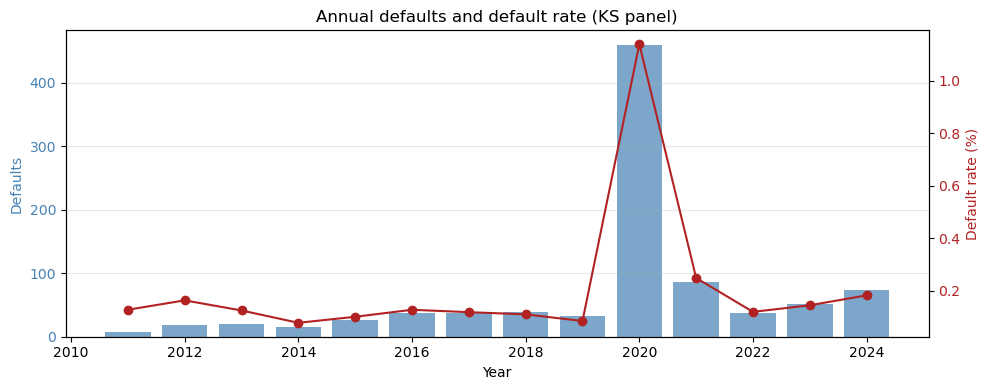

In [8]:
# Default rate per year — compare to paper Fig 1
yearly_rate = yearly.groupby('year').agg(
    n_loans=('loan_sequence_number', 'count'),
    n_default=('default_in_year', 'sum'),
    n_prepay=('prepay_in_year', 'sum'),
)
yearly_rate['default_rate'] = 100 * yearly_rate['n_default'] / yearly_rate['n_loans']
yearly_rate['prepay_rate'] = 100 * yearly_rate['n_prepay'] / yearly_rate['n_loans']
print(yearly_rate.to_string())

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.bar(yearly_rate.index, yearly_rate['n_default'], color='steelblue', alpha=0.7, label='Defaults (left)')
ax1.set_xlabel('Year')
ax1.set_ylabel('Defaults', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(yearly_rate.index, yearly_rate['default_rate'], color='firebrick', marker='o', label='Default rate (right)')
ax2.set_ylabel('Default rate (%)', color='firebrick')
ax2.tick_params(axis='y', labelcolor='firebrick')
ax1.grid(True, alpha=0.3, axis='y')
plt.title('Annual defaults and default rate (KS panel)')
plt.tight_layout()
plt.savefig('../figures/22_kundig_sigrist/annual_default_rate.png', dpi=150, bbox_inches='tight')
plt.show()

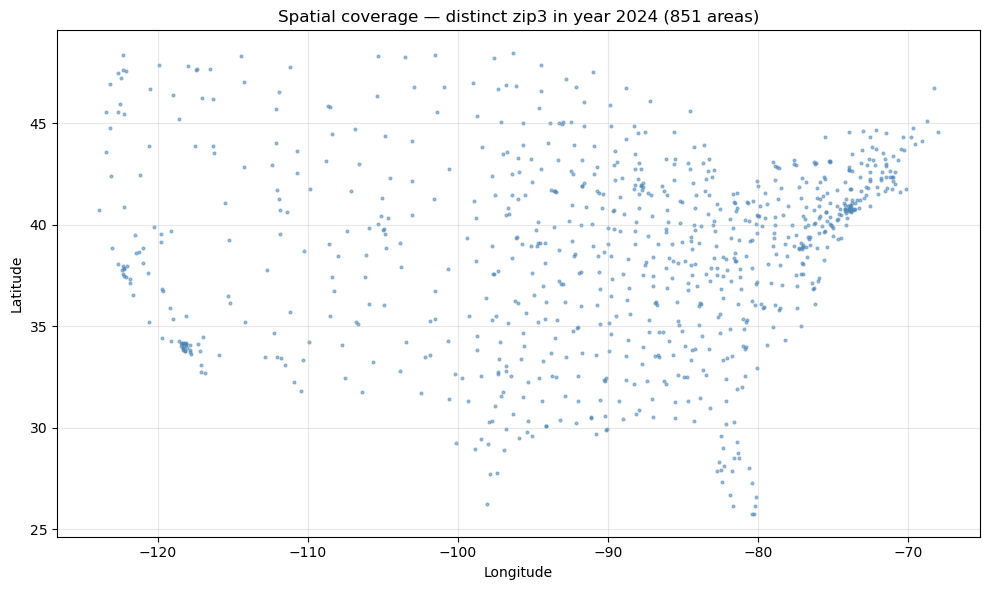

In [9]:
# Spatial coverage map (one snapshot — most recent year)
year_show = int(yearly['year'].max())
sub = yearly[yearly['year'] == year_show].drop_duplicates('zip3')[['zip3', 'lat', 'lon']]
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(sub['lon'], sub['lat'], s=4, alpha=0.5, color='steelblue')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Spatial coverage — distinct zip3 in year {year_show} ({len(sub):,} areas)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/22_kundig_sigrist/spatial_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Save the panel

In [10]:
out_path = DATA_PROCESSED / 'kundig_sigrist_yearly_panel.parquet'
yearly.to_parquet(out_path, index=False)
print(f'Saved: {out_path}')
print(f'  {len(yearly):,} rows, {yearly["loan_sequence_number"].nunique():,} loans, '
      f'{len(yearly.columns)} columns, '
      f'{out_path.stat().st_size / 1e6:.1f} MB on disk')

Saved: ../data/processed/kundig_sigrist_yearly_panel.parquet
  397,577 rows, 93,650 loans, 24 columns, 9.1 MB on disk


## Summary

- One row per (loan, calendar year) where the loan was active at the start of the year and originated before that year.
- Outcomes: `prepay_in_year`, `default_in_year` (mutually exclusive).
- Predictors: canonical 13 + `lat` / `lon` + `n_months` + `ir_spread`.
- Spatial: 3-digit zip → centroid via pgeocode US database.
- Filters: contiguous US, full calendar years only.

Fold assignment is preserved from the source panel for cross-model comparison.